# 📈 Análise de Séries Temporais em R

Este notebook apresenta o **procedimento completo** para análise de séries temporais, seguindo a metodologia clássica:

1. Carregamento e visualização dos dados
2. Decomposição da série
3. Teste de estacionariedade
4. Transformações (se necessário)
5. Identificação do modelo (ACF / PACF)
6. Ajuste do modelo ARIMA
7. Diagnóstico dos resíduos
8. Previsão (*forecast*)

> Usaremos a série clássica `AirPassengers` — passageiros mensais de companhias aéreas de 1949 a 1960.

---
## 0. Instalação e carregamento de pacotes

Os principais pacotes que usaremos:

| Pacote | Finalidade |
|--------|------------|
| `forecast` | Modelagem ARIMA e previsão |
| `tseries` | Testes de estacionariedade |
| `ggplot2` | Visualizações |
| `zoo` | Manipulação de séries temporais |

In [ ]:
library(forecast)
library(tseries)
library(ggplot2)
library(zoo)

cat("Pacotes carregados com sucesso!\n")

Pacotes carregados com sucesso!


---
## 1. Carregamento e visualização inicial

O primeiro passo é **olhar para os dados**. Queremos entender:
- Existe **tendência** (crescimento ou queda ao longo do tempo)?
- Existe **sazonalidade** (padrões que se repetem periodicamente)?
- Há **outliers** ou quebras estruturais?
- A variância é **constante** ou cresce com o nível da série?

In [ ]:
data(AirPassengers)
ts_data <- AirPassengers

dados <- read.csv("eggs.csv")

ts_data <- dados

In [1]:
# Carregando a série clássica AirPassengers
data(AirPassengers)
ts_data <- AirPassengers

# Informações básicas
cat("Classe:", class(ts_data), "\n")
cat("Início:", start(ts_data), "\n")
cat("Fim:", end(ts_data), "\n")
cat("Frequência:", frequency(ts_data), "observações/ano\n")
cat("Comprimento:", length(ts_data), "observações\n")
cat("\nResumo estatístico:\n")
print(summary(ts_data))

Classe: ts 
Início: 1949 1 
Fim: 1960 12 
Frequência: 12 observações/ano
Comprimento: 144 observações

Resumo estatístico:
   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
  104.0   180.0   265.5   280.3   360.5   622.0 


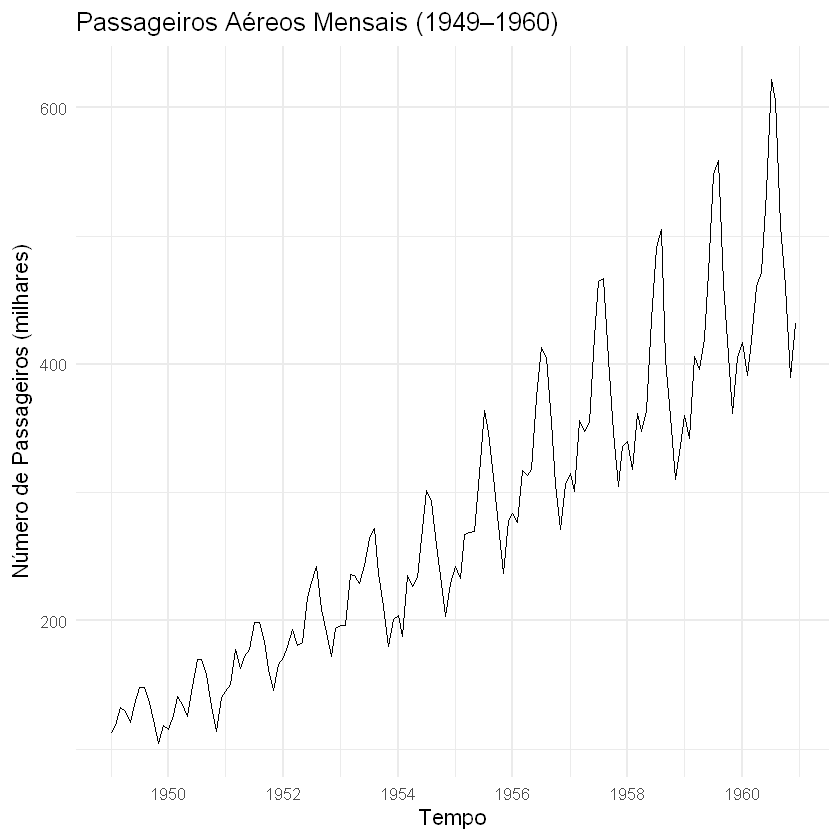

In [5]:
# Visualização da série original
autoplot(ts_data) +
  labs(
    title = "Passageiros Aéreos Mensais (1949–1960)",
    x = "Tempo",
    y = "Número de Passageiros (milhares)"
  ) +
  theme_minimal(base_size = 13)

**Observações da visualização:**

- Há uma **tendência crescente** clara ao longo do tempo.
- A sazonalidade é **multiplicativa**: os picos de verão crescem proporcionalmente ao nível da série.
- Isso sugere que pode ser necessária uma **transformação logarítmica** para estabilizar a variância antes de modelar.

---
## 2. Decomposição da série

A decomposição separa a série em seus componentes fundamentais:

$$Y_t = T_t \times S_t \times R_t \quad \text{(modelo multiplicativo)}$$

- $T_t$ = **Tendência** (*trend*)
- $S_t$ = **Sazonalidade** (*seasonal*)
- $R_t$ = **Resíduo** (*remainder*)

Usamos `decompose()` (média móvel clássica) ou `stl()` (mais robusto).

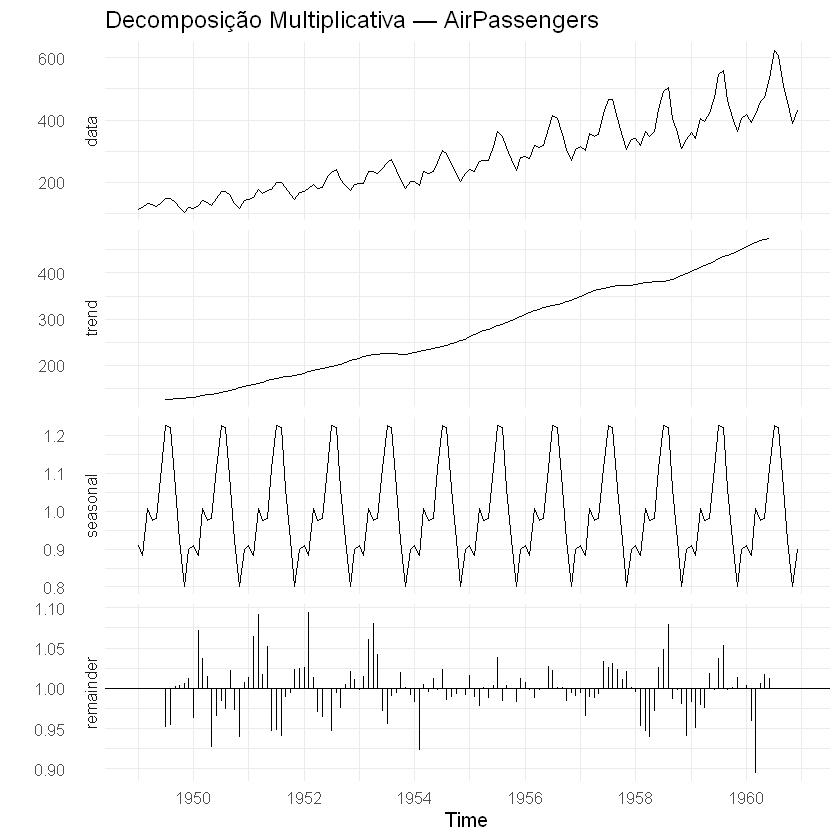

In [6]:
# Decomposição multiplicativa clássica
decomp <- decompose(ts_data, type = "multiplicative")
autoplot(decomp) +
  labs(title = "Decomposição Multiplicativa — AirPassengers") +
  theme_minimal(base_size = 12)

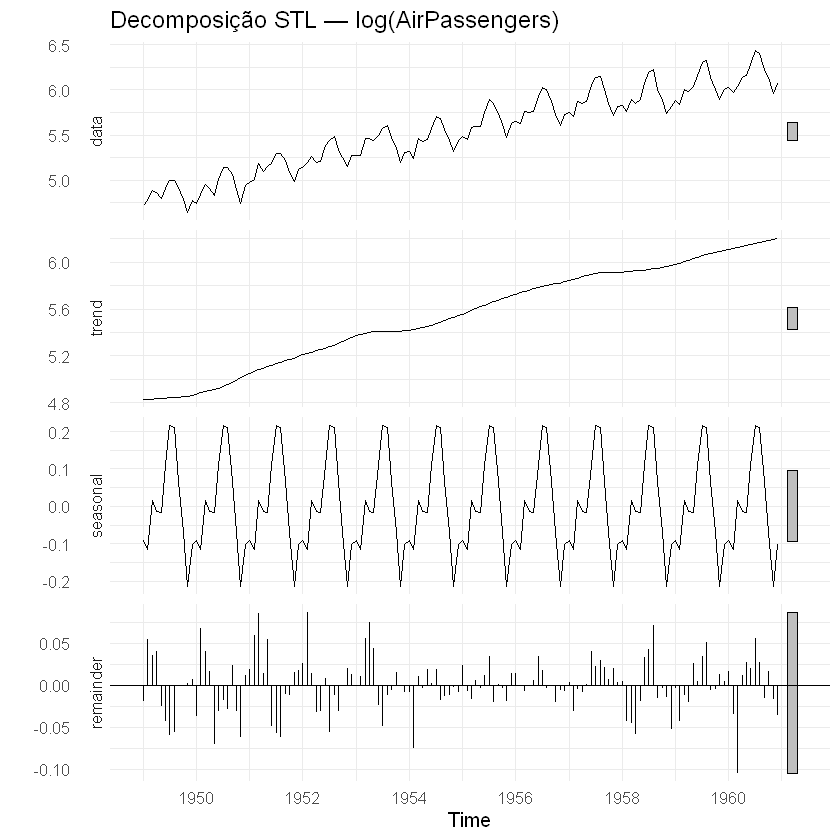

In [7]:
# STL: Seasonal and Trend decomposition using Loess
# Mais robusto a outliers e permite sazonalidade variante
stl_decomp <- stl(log(ts_data), s.window = "periodic")
autoplot(stl_decomp) +
  labs(title = "Decomposição STL — log(AirPassengers)") +
  theme_minimal(base_size = 12)

---
## 3. Teste de Estacionariedade

Modelos ARIMA exigem que a série seja **estacionária** — ou seja, média, variância e autocovariância constantes no tempo.

### Teste ADF (Augmented Dickey-Fuller)
- $H_0$: a série **tem raiz unitária** (não é estacionária)
- $H_1$: a série **é estacionária**
- Se $p < 0{,}05$ → rejeitamos $H_0$ → série é estacionária

### Teste KPSS
- $H_0$: a série **é estacionária**
- $H_1$: a série **tem raiz unitária**
- Se $p < 0{,}05$ → rejeitamos $H_0$ → série NÃO é estacionária

In [8]:
cat("=== Teste ADF — Série Original ===", "\n")
adf.test(ts_data)


=== Teste ADF — Série Original === 


Warning message in adf.test(ts_data):
"p-value smaller than printed p-value"



	Augmented Dickey-Fuller Test

data:  ts_data
Dickey-Fuller = -7.3186, Lag order = 5, p-value = 0.01
alternative hypothesis: stationary


In [9]:
cat("=== Teste KPSS — Série Original ===", "\n")
kpss.test(ts_data)

=== Teste KPSS — Série Original === 


Warning message in kpss.test(ts_data):
"p-value smaller than printed p-value"



	KPSS Test for Level Stationarity

data:  ts_data
KPSS Level = 2.7395, Truncation lag parameter = 4, p-value = 0.01


**Interpretação:** A série original claramente não é estacionária (tendência evidente). Precisamos aplicar transformações.

---
## 4. Transformações para Estacionarizar

### Passo 1 — Log para estabilizar a variância
### Passo 2 — Diferenciação sazonal (lag=12) para remover a sazonalidade
### Passo 3 — Diferenciação simples (lag=1) para remover a tendência

A notação ARIMA usa $d$ (diferenças simples) e $D$ (diferenças sazonais).

In [10]:
# Verificando quantas diferenças são necessárias automaticamente
ts_log <- log(ts_data)

cat("Diferenças simples sugeridas (ndiffs):", ndiffs(ts_log), "\n")
cat("Diferenças sazonais sugeridas (nsdiffs):", nsdiffs(ts_log), "\n")

Diferenças simples sugeridas (ndiffs): 1 
Diferenças sazonais sugeridas (nsdiffs): 1 


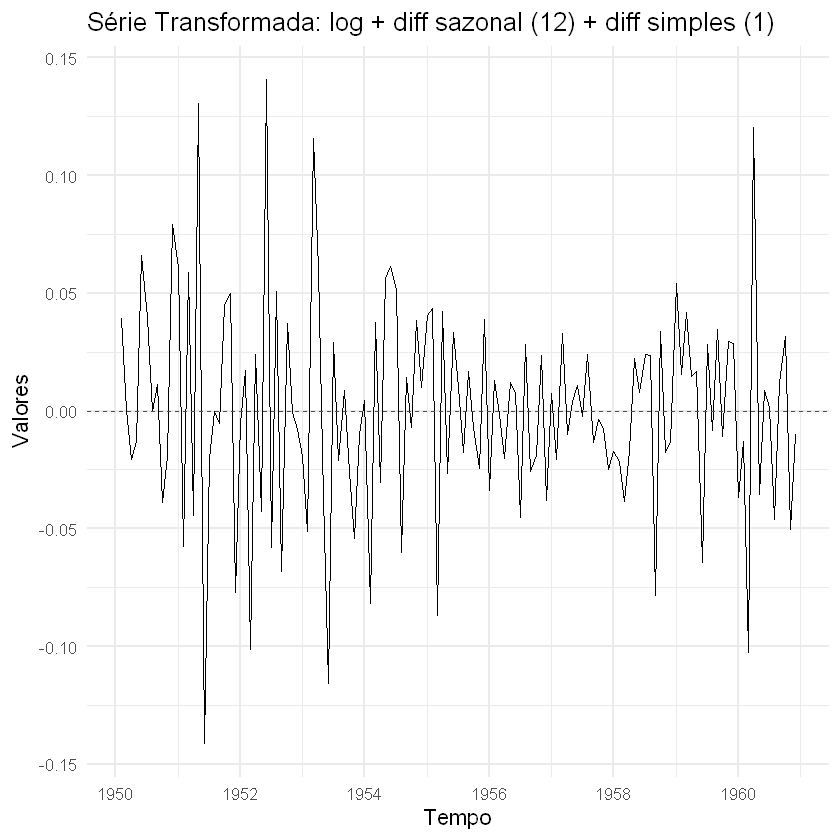

In [11]:
# Aplicando as transformações
ts_log_diff <- diff(diff(ts_log, lag = 12), lag = 1)

# Visualizando
autoplot(ts_log_diff) +
  labs(
    title = "Série Transformada: log + diff sazonal (12) + diff simples (1)",
    x = "Tempo", y = "Valores"
  ) +
  geom_hline(yintercept = 0, linetype = "dashed", color = "red") +
  theme_minimal(base_size = 13)

In [12]:
# Retestando a estacionariedade após transformação
cat("=== Teste ADF — Série Transformada ===", "\n")
adf.test(ts_log_diff)

cat("\n=== Teste KPSS — Série Transformada ===", "\n")
kpss.test(ts_log_diff)

=== Teste ADF — Série Transformada === 


Warning message in adf.test(ts_log_diff):
"p-value smaller than printed p-value"



	Augmented Dickey-Fuller Test

data:  ts_log_diff
Dickey-Fuller = -5.1993, Lag order = 5, p-value = 0.01
alternative hypothesis: stationary



=== Teste KPSS — Série Transformada === 


Warning message in kpss.test(ts_log_diff):
"p-value greater than printed p-value"



	KPSS Test for Level Stationarity

data:  ts_log_diff
KPSS Level = 0.084365, Truncation lag parameter = 4, p-value = 0.1


---
## 5. Identificação do Modelo — ACF e PACF

Com a série estacionária, analisamos os **correlogramas** para identificar as ordens $p$, $q$, $P$, $Q$ do modelo SARIMA.

| Gráfico | O que revela |
|---------|-------------|
| **ACF** (Autocorrelation Function) | Ordem $q$ do MA — cortes após o lag $q$ |
| **PACF** (Partial Autocorrelation Function) | Ordem $p$ do AR — cortes após o lag $p$ |

Para a parte sazonal, observamos os lags múltiplos de 12 (no caso mensal).

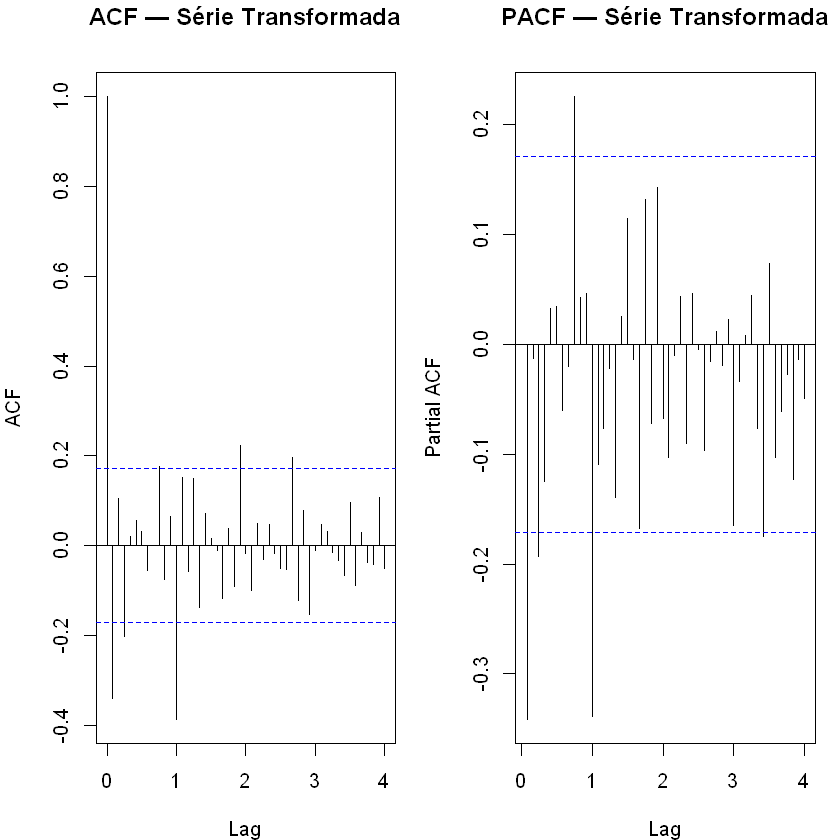

In [13]:
par(mfrow = c(1, 2), mar = c(4, 4, 3, 1))

acf(ts_log_diff, lag.max = 48, main = "ACF — Série Transformada")
pacf(ts_log_diff, lag.max = 48, main = "PACF — Série Transformada")

**Leitura dos correlogramas:**

- **ACF**: corte significativo no lag 1 e no lag 12 → sugere $q=1$ e $Q=1$
- **PACF**: padrão de decaimento → parte AR pode ser 0 ou 1

Candidato: **SARIMA(0,1,1)(0,1,1)[12]** — o famoso modelo "airline" de Box & Jenkins.

---
## 6. Ajuste do Modelo ARIMA

Podemos tanto **especificar manualmente** quanto usar o `auto.arima()` que testa automaticamente as combinações via critério de informação (AIC/BIC).

In [14]:
# Modelo manual — SARIMA(0,1,1)(0,1,1)[12]
modelo_manual <- Arima(
  ts_log,
  order    = c(0, 1, 1),
  seasonal = list(order = c(0, 1, 1), period = 12)
)

cat("=== Modelo Manual: SARIMA(0,1,1)(0,1,1)[12] ===\n")
summary(modelo_manual)

=== Modelo Manual: SARIMA(0,1,1)(0,1,1)[12] ===


Series: ts_log 
ARIMA(0,1,1)(0,1,1)[12] 

Coefficients:
          ma1     sma1
      -0.4018  -0.5569
s.e.   0.0896   0.0731

sigma^2 = 0.001371:  log likelihood = 244.7
AIC=-483.4   AICc=-483.21   BIC=-474.77

Training set error measures:
                       ME       RMSE        MAE        MPE      MAPE      MASE
Training set 0.0005730622 0.03504883 0.02626034 0.01098898 0.4752815 0.2169522
                   ACF1
Training set 0.01443892

In [15]:
# Seleção automática com auto.arima
# stepwise=FALSE e approximation=FALSE = busca mais completa (mais lenta)
modelo_auto <- auto.arima(
  ts_log,
  stepwise      = FALSE,
  approximation = FALSE,
  trace         = TRUE
)

cat("\n=== Modelo Auto-selecionado ===\n")
summary(modelo_auto)


 ARIMA(0,1,0)(0,1,0)[12]                    : -434.799
 ARIMA(0,1,0)(0,1,1)[12]                    : -467.4644
 ARIMA(0,1,0)(0,1,2)[12]                    : -465.3757
 ARIMA(0,1,0)(1,1,0)[12]                    : -456.9255
 ARIMA(0,1,0)(1,1,1)[12]                    : -465.3748
 ARIMA(0,1,0)(1,1,2)[12]                    : -463.2847
 ARIMA(0,1,0)(2,1,0)[12]                    : -461.5081
 ARIMA(0,1,0)(2,1,1)[12]                    : -463.4698
 ARIMA(0,1,0)(2,1,2)[12]                    : Inf
 ARIMA(0,1,1)(0,1,0)[12]                    : -449.8857
 ARIMA(0,1,1)(0,1,1)[12]                    : -483.2101
 ARIMA(0,1,1)(0,1,2)[12]                    : -481.6451
 ARIMA(0,1,1)(1,1,0)[12]                    : -477.2164
 ARIMA(0,1,1)(1,1,1)[12]                    : -481.5957
 ARIMA(0,1,1)(1,1,2)[12]                    : Inf
 ARIMA(0,1,1)(2,1,0)[12]                    : -479.1612
 ARIMA(0,1,1)(2,1,1)[12]                    : -479.4546
 ARIMA(0,1,1)(2,1,2)[12]                    : Inf
 ARIMA(0,1

Series: ts_log 
ARIMA(0,1,1)(0,1,1)[12] 

Coefficients:
          ma1     sma1
      -0.4018  -0.5569
s.e.   0.0896   0.0731

sigma^2 = 0.001371:  log likelihood = 244.7
AIC=-483.4   AICc=-483.21   BIC=-474.77

Training set error measures:
                       ME       RMSE        MAE        MPE      MAPE      MASE
Training set 0.0005730622 0.03504883 0.02626034 0.01098898 0.4752815 0.2169522
                   ACF1
Training set 0.01443892

In [16]:
# Comparação de critérios de informação
cat("=== Comparação de Modelos ===\n")
cat(sprintf("Modelo Manual  — AIC: %.2f | BIC: %.2f\n", AIC(modelo_manual), BIC(modelo_manual)))
cat(sprintf("Modelo Auto    — AIC: %.2f | BIC: %.2f\n", AIC(modelo_auto),   BIC(modelo_auto)))

=== Comparação de Modelos ===
Modelo Manual  — AIC: -483.40 | BIC: -474.77
Modelo Auto    — AIC: -483.40 | BIC: -474.77


---
## 7. Diagnóstico dos Resíduos

Um bom modelo deve ter resíduos que se comportem como **ruído branco**:

- Média ≈ 0
- Variância constante (homocedasticidade)
- Sem autocorrelação significativa
- Distribuição aproximadamente normal

Usamos o **Teste de Ljung-Box**: $H_0$ = não há autocorrelação nos resíduos.


	Ljung-Box test

data:  Residuals from ARIMA(0,1,1)(0,1,1)[12]
Q* = 26.446, df = 22, p-value = 0.233

Model df: 2.   Total lags used: 24



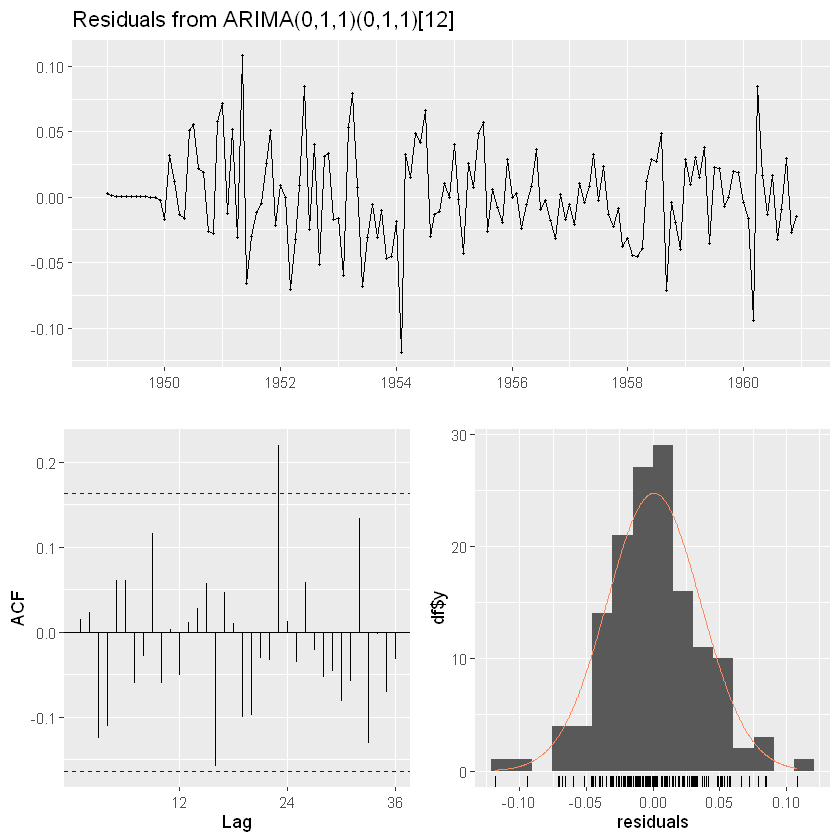

In [17]:
# Diagnóstico visual completo
checkresiduals(modelo_manual)

In [18]:
# Teste de Ljung-Box formal
res <- residuals(modelo_manual)

lb_test <- Box.test(res, lag = 24, type = "Ljung-Box", fitdf = 2)
cat("=== Teste de Ljung-Box (lag=24) ===\n")
print(lb_test)

if (lb_test$p.value > 0.05) {
  cat("\n✅ p >", 0.05, "→ Não rejeitamos H0: resíduos sem autocorrelação (bom!)\n")
} else {
  cat("\n⚠️  p <", 0.05, "→ Resíduos com autocorrelação. Reconsidere o modelo.\n")
}

=== Teste de Ljung-Box (lag=24) ===

	Box-Ljung test

data:  res
X-squared = 26.446, df = 22, p-value = 0.233


✅ p > 0.05 → Não rejeitamos H0: resíduos sem autocorrelação (bom!)


=== Teste de Shapiro-Wilk (normalidade) ===

	Shapiro-Wilk normality test

data:  as.numeric(res)
W = 0.98637, p-value = 0.1674



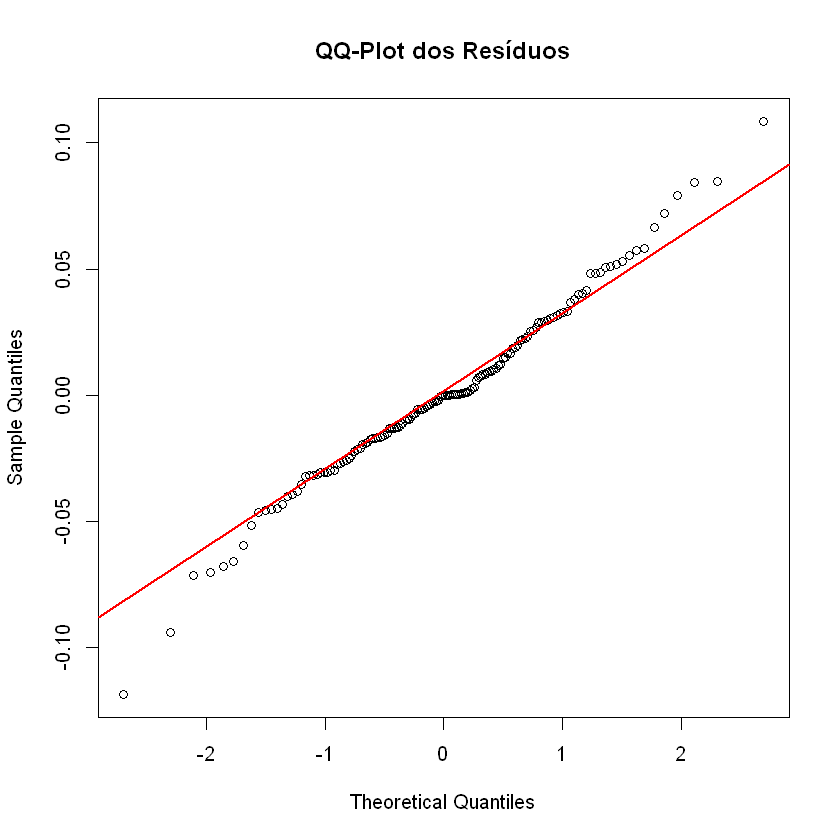

In [19]:
# Teste de normalidade dos resíduos — Shapiro-Wilk
sw_test <- shapiro.test(as.numeric(res))
cat("=== Teste de Shapiro-Wilk (normalidade) ===\n")
print(sw_test)

# QQ-plot
qqnorm(res, main = "QQ-Plot dos Resíduos")
qqline(res, col = "red", lwd = 2)

---
## 8. Previsão (*Forecast*)

Com o modelo validado, geramos previsões. Como trabalhamos com `log(ts_data)`, precisamos **reverter a transformação** com `exp()` para interpretar na escala original.

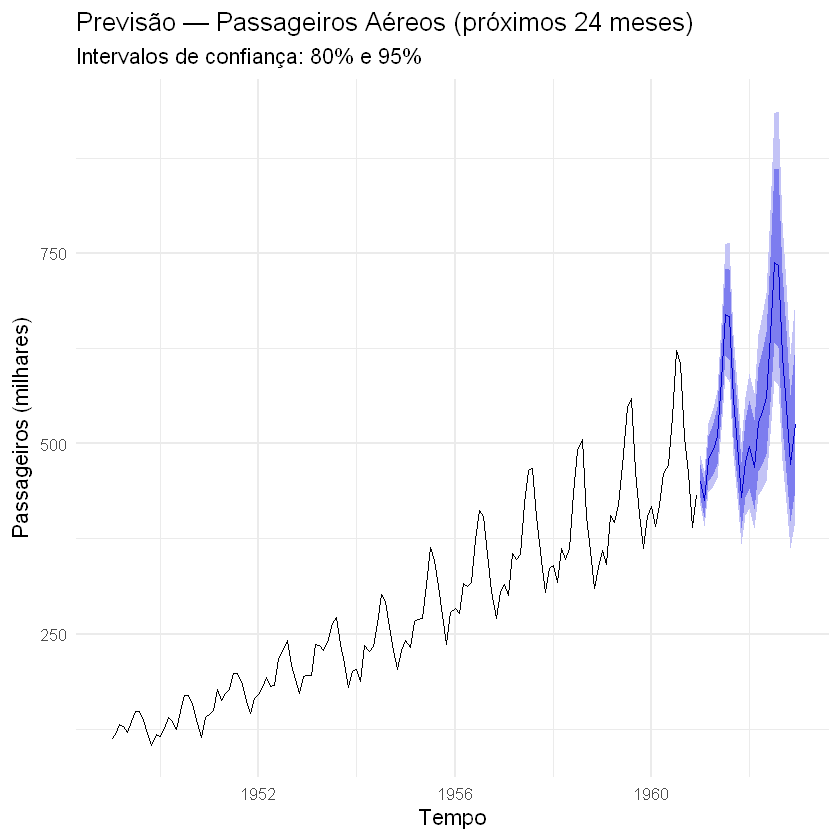

In [20]:
# Gerando previsão para os próximos 24 meses
h <- 24  # horizonte de previsão

previsao_log <- forecast(modelo_manual, h = h, level = c(80, 95))

# Revertendo a transformação logarítmica
previsao_orig <- previsao_log
previsao_orig$mean  <- exp(previsao_log$mean)
previsao_orig$lower <- exp(previsao_log$lower)
previsao_orig$upper <- exp(previsao_log$upper)
previsao_orig$x     <- exp(previsao_log$x)

# Plot
autoplot(previsao_orig) +
  labs(
    title    = "Previsão — Passageiros Aéreos (próximos 24 meses)",
    subtitle = "Intervalos de confiança: 80% e 95%",
    x        = "Tempo",
    y        = "Passageiros (milhares)"
  ) +
  theme_minimal(base_size = 13)

In [21]:
# Tabela com os valores previstos
df_prev <- data.frame(
  Período    = as.character(time(previsao_orig$mean)),
  Previsão   = round(as.numeric(previsao_orig$mean), 1),
  `IC 80% Lo` = round(as.numeric(previsao_orig$lower[, 1]), 1),
  `IC 80% Hi` = round(as.numeric(previsao_orig$upper[, 1]), 1),
  `IC 95% Lo` = round(as.numeric(previsao_orig$lower[, 2]), 1),
  `IC 95% Hi` = round(as.numeric(previsao_orig$upper[, 2]), 1)
)
print(df_prev)

            Período Previsão IC.80..Lo IC.80..Hi IC.95..Lo IC.95..Hi
1              1961    450.4     429.5     472.3     418.9     484.3
2  1961.08333333334    425.7     402.8     449.9     391.2     463.3
3  1961.16666666667    479.0     450.1     509.7     435.6     526.8
4           1961.25    492.4     459.9     527.2     443.5     546.7
5  1961.33333333334    509.1     472.7     548.2     454.6     570.0
6  1961.41666666667    583.3     538.9     631.5     516.8     658.5
7            1961.5    670.0     615.9     728.9     589.1     762.1
8  1961.58333333334    667.1     610.4     729.1     582.3     764.2
9  1961.66666666667    558.2     508.5     612.8     484.0     643.8
10          1961.75    497.2     451.0     548.1     428.3     577.2
11 1961.83333333334    429.9     388.4     475.8     368.0     502.1
12 1961.91666666667    477.2     429.5     530.3     406.2     560.7
13             1962    495.9     441.4     557.2     415.0     592.6
14 1962.08333333334    468.7     4

---
## 9. Avaliação da Acurácia (Validação Cruzada Temporal)

Para avaliar o modelo de forma mais rigorosa, usamos **validação cruzada temporal** (*time series cross-validation*): treinamos em janelas crescentes e avaliamos o erro de previsão.

In [22]:
# Hold-out simples: treinamento até 1958, teste 1959-1960
treino <- window(ts_log, end = c(1958, 12))
teste  <- window(ts_log, start = c(1959, 1))

modelo_treino <- Arima(treino, order = c(0,1,1), seasonal = list(order = c(0,1,1), period = 12))
prev_teste    <- forecast(modelo_treino, h = length(teste))

# Métricas de acurácia
acc <- accuracy(prev_teste, teste)
cat("=== Métricas de Acurácia (escala log) ===\n")
print(round(acc, 4))

=== Métricas de Acurácia (escala log) ===
                  ME   RMSE    MAE     MPE   MAPE   MASE   ACF1 Theil's U
Training set -0.0001 0.0354 0.0264 -0.0004 0.4867 0.2145 0.0058        NA
Test set      0.0896 0.0959 0.0896  1.4635 1.4635 0.7279 0.3280    0.8735


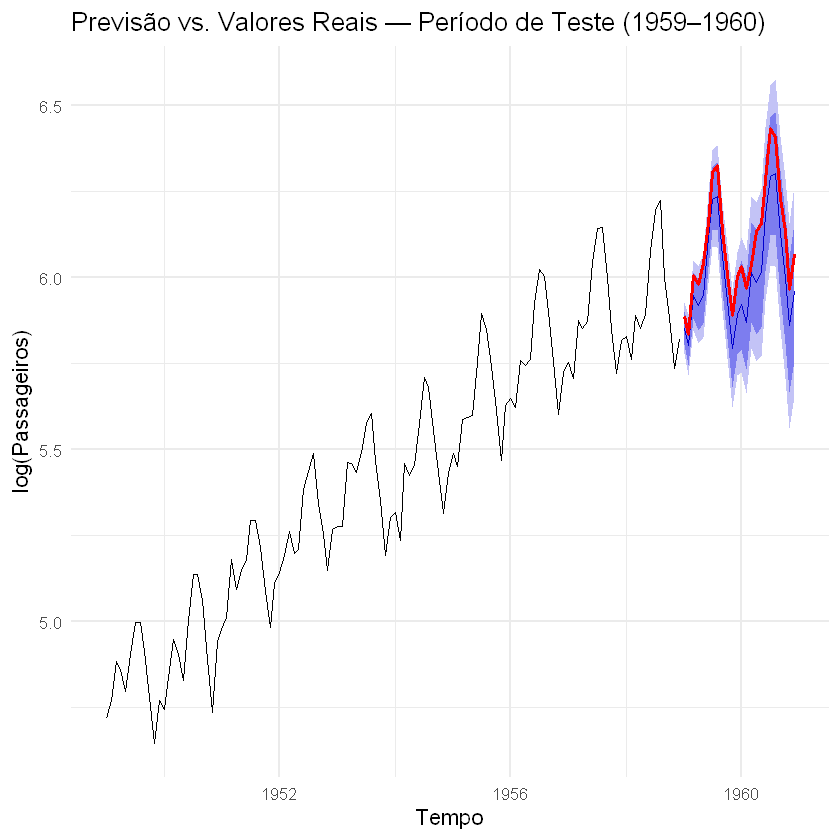

In [23]:
# Visualização: previsão vs. valores reais no período de teste
autoplot(prev_teste) +
  autolayer(teste, series = "Valores Reais", color = "red", lwd = 1) +
  labs(
    title    = "Previsão vs. Valores Reais — Período de Teste (1959–1960)",
    x        = "Tempo",
    y        = "log(Passageiros)",
    color    = "Série"
  ) +
  theme_minimal(base_size = 13)

---
## 🗂️ Resumo do Fluxo de Análise

```
Dados Brutos
     │
     ▼
Visualização ──► Tendência? Sazonalidade? Variância crescente?
     │
     ▼
Decomposição (decompose / STL)
     │
     ▼
Teste de Estacionariedade (ADF, KPSS)
     │
     ▼ [se não estacionária]
Transformações: log → diff sazonal → diff simples
     │
     ▼
ACF / PACF ──► Identificar p, q, P, Q
     │
     ▼
Ajuste do Modelo ARIMA / SARIMA
     │
     ▼
Diagnóstico dos Resíduos (Ljung-Box, Shapiro-Wilk, QQ-plot)
     │
     ▼
Previsão + Intervalos de Confiança
     │
     ▼
Avaliação de Acurácia (RMSE, MAE, MAPE)
```

### Métricas comuns de avaliação

| Métrica | Fórmula | Interpretação |
|---------|---------|---------------|
| **MAE** | $\frac{1}{n}\sum|y_t - \hat{y}_t|$ | Erro médio absoluto (mesma unidade dos dados) |
| **RMSE** | $\sqrt{\frac{1}{n}\sum(y_t-\hat{y}_t)^2}$ | Penaliza erros grandes |
| **MAPE** | $\frac{100}{n}\sum\left|\frac{y_t-\hat{y}_t}{y_t}\right|$ | Erro percentual — fácil de interpretar |

---
*Notebook criado para análise completa de séries temporais com R. Modelo utilizado: SARIMA(0,1,1)(0,1,1)[12] — "Airline Model" de Box & Jenkins (1970).*